In [23]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [24]:
# plotData Plots the data points x and y into a new figure.
# PlotData(x,y) plots the data points and gives the figure axes labels of population and profit.
    
def plotData(x, y):
    plt.plot(x, y, linestyle='', marker='x', color='r', label='Training data')
    plt.xlabel('Population of City in 10,000s')
    plt.ylabel('Profit in $10,000s')

In [25]:
# plotHypothesis plots the hypothesis line

def plotHypothesis(X, y, theta):    
    plotData(X[:, 1], y)
    plt.plot(X[:, 1], X.dot(theta), label='Linear Regression')
    plt.legend(loc='upper left', numpoints=1)
    plt.show()

In [26]:
# plotCost plots the convergence graph

def plotCost(j):
    plt.plot(j)
    plt.xlabel('Number of iterations')
    plt.ylabel('Cost J')
    plt.show()

In [73]:
# calculateHypothesis calculates the hypothesis for a given X, theta and specified training example

def calculateHypothesis(X, theta, trainingExample):

    # this hypothesis makes a flat hypothesis and also a flat cost graph
    hypothesis = 0.0

    # --------------------------- your code ------------------------------
    # this hypothesis returns the predicted value for a single variable
    hypothesis = np.dot(X[trainingExample],theta)
#     print(f'hypothesis=  {hypothesis}')
#     print(f'X[trainingExample]=  {X[trainingExample]}')
#     print(f'theta[1]=  {theta[1]}')
    return hypothesis

In [74]:
# computeCost Compute cost for linear regression
# J = computeCost(X, y, theta) computes the cost of using theta as the parameter for linear regression
# to fit the data points in X and y.
    
def computeCost(X, y, theta):
    j = 0.0
    m = len(y) # number of training examples

    for i in range(m):
        hypothesis = calculateHypothesis(X, theta, i)
        output = y[i]
        squaredError = math.pow((hypothesis - output), 2)
        j = j + squaredError

    j = j * (1.0 / (2 * m))

    return j

In [75]:
# gradientDescent do Gradient Descent for a given X, y, theta, alpha for a specified number of iterations

def gradientDescent(X, y, theta, alpha, num_iters):
    m = len(y)       # number of training examples
    cost_vector = [] # will store the results of our cost function

    plotHypothesis(X, y, theta)

    for iter in range(num_iters):
        theta_0 = theta[0]
        theta_1 = theta[1]

        # update theta0 and store in temporary variable theta_0
        sigma = 0.0

        for i in range(m):
            hypothesis = calculateHypothesis(X, theta, i)
            output = y[i]
            sigma = sigma + (hypothesis - output)

        theta_0 = theta_0 - ((alpha * 1.0) / m) * sigma

        # update theta1 and store in temporary variable theta_1
        sigma = 0.0

        for i in range(m):
            hypothesis = calculateHypothesis(X, theta, i)
            output = y[i]
            sigma = sigma + (hypothesis - output) * X[i, 1]

        theta_1 = theta_1 - ((alpha * 1.0) / m) * sigma

        # update theta
        theta = [theta_0, theta_1]

        if(iter % 25 == 0):
            plotHypothesis(X, y, theta)

        # update cost vector
        cost_vector = np.append(cost_vector, computeCost(X, y, theta))

    return theta, cost_vector

Plotting Data ...



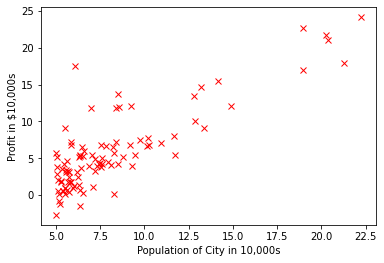

In [81]:
# ======================= Load and plot data =======================

print('Plotting Data ...\n')
data = open('ex1data1.txt', 'rb')
lines = data.readlines()
lines = [l.decode('UTF-8').split(',') for l in lines]

X = [float(l[0]) for l in lines]
y = np.array([float(l[1]) for l in lines])
m = len(y) # number of training examples
# print(X[0])
# Plot data
plotData(X, y)
plt.show()

Running Gradient Descent...
cost= 32.072733877455654


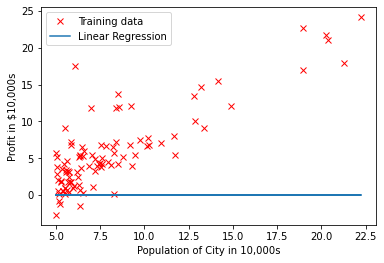

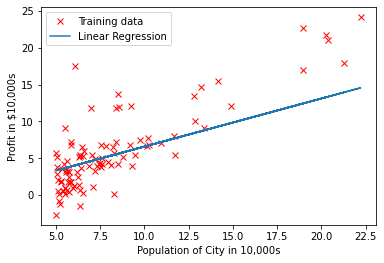

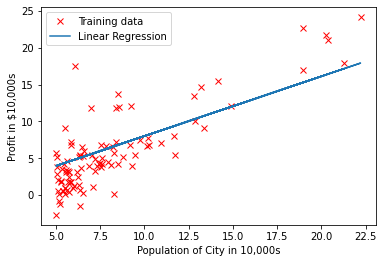

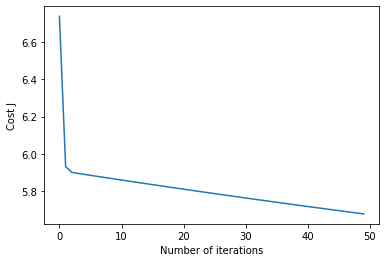

In [77]:
# =================== Gradient descent ===================

print('Running Gradient Descent...')

X = np.array([[1.0, x] for x in X]) # Add a column of ones to x

# Initialize fitting parameters
theta = np.zeros((2))

# Some gradient descent settings
iterations = 50
alpha = 0.01

# Compute and display initial cost
cost = computeCost(X, y, theta)
print ('cost=',cost)

# Run gradient descent
theta, j = gradientDescent(X, y, theta, alpha, iterations)

# Plot the convergence graph
plotCost(j)

Theta found by gradient descent: [-0.2632037884437438, 0.8281018736080105]


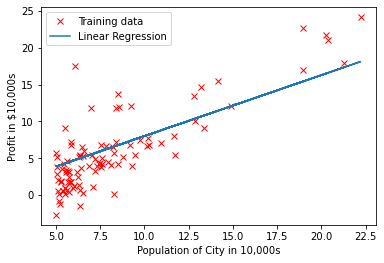

In [78]:
# =================== Model ===================

# Print theta to screen
print ('Theta found by gradient descent:', theta)

# plot the line
plotHypothesis(X,y,theta)

In [79]:
# =================== Prediction ===================

# Predict values for population sizes of 35,000 and 70,000
# predict1 = np.array([1, 3.5]).dot(theta)
# print('For population = 35,000, we predict a profit of', predict1 * 10000)

# --------------------------- your code ------------------------------
predict1 = np.array([1, 3.5]).dot(theta)
print('For population = 35,000, we predict a profit of', predict1 * 10000)

predict1 = np.array([1, 7]).dot(theta)
print('For population = 70,000, we predict a profit of', predict1 * 10000)

For population = 35,000, we predict a profit of 26351.52769184293
For population = 70,000, we predict a profit of 55335.093268123295
